# 04 - Transformer + LoRA

## 1. Objetivo

Implementar la rama avanzada de clasificación temática utilizando un modelo Transformer preentrenado y ajuste eficiente mediante LoRA sobre el mismo corpus AG News utilizado en las etapas anteriores.

El entrenamiento se realizará en GPU mediante Google Colab. El modelo será evaluado sobre el conjunto de prueba oficial para obtener métricas comparables con el baseline clásico desarrollado en el Notebook 03.

## 2. Configuración del entorno

In [ ]:
import torch

print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers peft datasets accelerate

In [ ]:
!pip install -q --upgrade torchao==0.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.9 MB/s eta 0:00:00


In [ ]:
import torch
import transformers
import peft
import datasets
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)

print("\nGPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.13.1
PEFT: 0.19.1
Datasets: 4.0.0
Accelerate: 1.14.0

GPU disponible: True
GPU: Tesla T4


In [ ]:
!git clone https://github.com/Amilcarjf/proyecto_nlp_ds3.git

Cloning into 'proyecto_nlp_ds3'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 75 (delta 15), reused 69 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 2.65 MiB | 5.64 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
%cd proyecto_nlp_ds3

/content/proyecto_nlp_ds3


In [ ]:
!python -m pip install -e .

Obtaining file:///content/proyecto_nlp_ds3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for proyecto-nlp-ds3 (pyproject.toml) ... done
  Created wheel for proyecto-nlp-ds3: filename=proyecto_nlp_ds3-0.1.0-0.editable-py3-none-any.whl size=2815 sha256=8ae2e0a9f79fd4ba105b880217a323a313f5763ae3a828a1f71077df62250d0b
  Stored in directory: /tmp/pip-ephem-wheel-cache-f_orktg_/wheels/5a/5c/a8/d1673798ad813bcb4640bec8c96fcd6a00cc0b211f4b2daa4b
Successfully built proyecto-nlp-ds3


In [ ]:
from src.paths import PROJECT_ROOT, DATA_PROCESSED

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)

PROJECT_ROOT: /content/proyecto_nlp_ds3
DATA_PROCESSED: /content/proyecto_nlp_ds3/data/processed


In [ ]:
from pathlib import Path

print("Archivos en data/processed:")

for archivo in DATA_PROCESSED.iterdir():
    print("-", archivo.name)

Archivos en data/processed:
- ag_news_test_processed.csv
- ag_news_train_processed.csv


## 3. Importación de librerías

In [ ]:
# ==========================================
# Pandas
# ==========================================

import pandas as pd

# ==========================================
# Numpy
# ==========================================

import numpy as np

# ==========================================
# Transformers
# ==========================================

from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
from transformers import set_seed

# ==========================================
# Sklearn
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ==========================================
# Sklearn
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Torch
# ==========================================

import torch

# ==========================================
# Pathlib
# ==========================================

from pathlib import Path

# ==========================================
# Shutil
# ==========================================

import shutil

# ==========================================
# Rutas
# ==========================================

from src.paths import (
    PROJECT_ROOT,
    DATA_PROCESSED,
    OUTPUTS_FIGURES,
    OUTPUTS_LOGS,
    OUTPUTS_MODELS,
    OUTPUTS_METRICS,
    OUTPUTS_TABLES
)


## 4. Carga y verificación del corpus

Se reutilizan los conjuntos de entrenamiento y prueba preprocesados en el Notebook 02. Ambos splits se mantienen separados durante toda la rama Transformer.

Antes de convertir los datos al formato de Hugging Face, se verifica la presencia de las columnas necesarias, la ausencia de valores nulos y la distribución de clases.

In [ ]:
# ==========================================
# Rutas del corpus preprocesado
# ==========================================

train_path = DATA_PROCESSED / "ag_news_train_processed.csv"
test_path = DATA_PROCESSED / "ag_news_test_processed.csv"


# ==========================================
# Carga de datos
# ==========================================

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Registros de entrenamiento: {len(df_train)}")
print(f"Registros de prueba: {len(df_test)}")

print("\nColumnas disponibles:")
print(df_train.columns.tolist())

display(df_train.head())

Registros de entrenamiento: 8000
Registros de prueba: 2000

Columnas disponibles:
['text', 'label', 'num_words', 'text_processed']


,text,label,num_words,text_processed
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech,30,red hat appoint new cfo september web host ind...
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech,32,sprint sbc hotspot roam deal sprint sbc commun...
2,Radio Outage Grounds West Coast Flights. Airpo...,Business,31,radio outage ground west coast flights airport...
3,Hollywood lawsuits to strike Net pirates. Holl...,Sci_Tech,43,hollywood lawsuit strike net pirate hollywood ...
4,Custis Takes Control. Family and Tony Robbins ...,Sports,28,custis take control family tony robbin mature ...


In [ ]:
# ==========================================
# Verificación estructural
# ==========================================

columnas_requeridas = {"text_processed", "label"}

print(
    "Columnas requeridas en train:",
    columnas_requeridas.issubset(df_train.columns)
)

print(
    "Columnas requeridas en test:",
    columnas_requeridas.issubset(df_test.columns)
)


# ==========================================
# Valores nulos
# ==========================================

print("\nValores nulos en train:")
print(df_train[["text_processed", "label"]].isnull().sum())

print("\nValores nulos en test:")
print(df_test[["text_processed", "label"]].isnull().sum())


# ==========================================
# Distribución de clases
# ==========================================

print("\nDistribución de clases en train:")
print(df_train["label"].value_counts())

print("\nDistribución de clases en test:")
print(df_test["label"].value_counts())

Columnas requeridas en train: True
Columnas requeridas en test: True

Valores nulos en train:
text_processed    0
label             0
dtype: int64

Valores nulos en test:
text_processed    0
label             0
dtype: int64

Distribución de clases en train:
label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64

Distribución de clases en test:
label
World       500
Business    500
Sports      500
Sci_Tech    500
Name: count, dtype: int64


## 5. Conversión de etiquetas y preparación para Hugging Face

Los modelos de clasificación de Hugging Face esperan etiquetas numéricas. Por este motivo, las categorías textuales del corpus se convierten a identificadores enteros manteniendo una correspondencia explícita entre cada clase y su valor numérico.

Posteriormente, los DataFrames de entrenamiento y prueba se transforman al formato `Dataset` de Hugging Face para continuar con la tokenización y el entrenamiento del Transformer.

In [ ]:
# ==========================================
# Mapeo de etiquetas
# ==========================================

label2id = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Sci_Tech": 3,
}

id2label = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci_Tech",
}


# ==========================================
# Conversión a enteros
# ==========================================

df_train["label_id"] = df_train["label"].map(label2id)
df_test["label_id"] = df_test["label"].map(label2id)


# ==========================================
# Verificación
# ==========================================

print("Mapeo de etiquetas:")
print(label2id)

print("\nValores únicos en train:")
print(sorted(df_train["label_id"].unique()))

print("\nValores únicos en test:")
print(sorted(df_test["label_id"].unique()))

display(
    df_train[
        ["label", "label_id"]
    ].drop_duplicates().sort_values("label_id")
)

Mapeo de etiquetas:
{'World': 0, 'Sports': 1, 'Business': 2, 'Sci_Tech': 3}

Valores únicos en train:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Valores únicos en test:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,label,label_id
16,World,0
4,Sports,1
2,Business,2
0,Sci_Tech,3


In [ ]:
# ==========================================
# Conversión a Hugging Face
# ==========================================

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    df_train[["text_processed", "label_id"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    df_test[["text_processed", "label_id"]],
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text_processed', 'label_id'],
    num_rows: 8000
})
Dataset({
    features: ['text_processed', 'label_id'],
    num_rows: 2000
})


In [ ]:
# ==========================================
# Renombrado de labels_id a labels
# ==========================================

train_dataset = train_dataset.rename_column(
    "label_id",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label_id",
    "labels"
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text_processed', 'labels'],
    num_rows: 8000
})
Dataset({
    features: ['text_processed', 'labels'],
    num_rows: 2000
})


## 6. Selección del modelo base y tokenización

Se selecciona `distilbert-base-uncased` como modelo Transformer preentrenado. La elección responde a que el corpus AG News está compuesto por textos en inglés y a que DistilBERT ofrece una arquitectura más liviana que BERT, reduciendo los requerimientos computacionales y el tiempo de entrenamiento.

Esta característica resulta adecuada para el ajuste mediante LoRA en una GPU Tesla T4 de Google Colab, manteniendo al mismo tiempo una representación contextual basada en un modelo preentrenado.

A partir del modelo seleccionado se utiliza su tokenizer correspondiente para transformar los documentos en secuencias de tokens compatibles con la entrada del Transformer.

In [ ]:
# ==========================================
# Selección del modelo y carga del tokenizer
# ==========================================

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Modelo seleccionado:", MODEL_NAME)
print("Tamaño del vocabulario:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Modelo seleccionado: distilbert-base-uncased
Tamaño del vocabulario: 30522


### Prueba de tokenización

Antes de tokenizar el corpus completo, se realiza una prueba sobre un único documento para verificar el funcionamiento del tokenizer y observar la representación generada.

El percentil 95 calculado durante el EDA del Notebook 02 fue de 53 tokens y constituye una referencia inicial para `max_length`. Sin embargo, este valor se verificará utilizando el tokenizer específico de DistilBERT, ya que este trabaja con subword tokens y su conteo puede diferir del utilizado durante el análisis exploratorio.

In [ ]:
# ==========================================
# Prueba de tokenización
# ==========================================

texto_ejemplo = train_dataset[0]["text_processed"]

tokens_ejemplo = tokenizer(
    texto_ejemplo,
    truncation=True,
    max_length=53
)

print("Texto:")
print(texto_ejemplo)

print("\nTokens:")
print(tokenizer.tokenize(texto_ejemplo))

print("\nInput IDs:")
print(tokens_ejemplo["input_ids"])

print("\nAttention mask:")
print(tokens_ejemplo["attention_mask"])

Texto:
red hat appoint new cfo september web host industry review linux distributor red hat redhat announce thursday appoint charles e peters jr

Tokens:
['red', 'hat', 'appoint', 'new', 'cf', '##o', 'september', 'web', 'host', 'industry', 'review', 'linux', 'distributor', 'red', 'hat', 'red', '##hat', 'announce', 'thursday', 'appoint', 'charles', 'e', 'peters', 'jr']

Input IDs:
[101, 2417, 6045, 16823, 2047, 12935, 2080, 2244, 4773, 3677, 3068, 3319, 11603, 16632, 2417, 6045, 2417, 12707, 14970, 9432, 16823, 2798, 1041, 12420, 3781, 102]

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## 7. Determinación de la longitud máxima de secuencia

El Notebook 02 estableció un percentil 95 de 53 palabras como referencia inicial para la longitud de los documentos. Sin embargo, el tokenizer de DistilBERT utiliza subword tokens, por lo que una palabra puede convertirse en más de un token.

Para definir `max_length` de acuerdo con la representación utilizada por el Transformer, se calcula nuevamente la longitud de las secuencias sobre el conjunto de entrenamiento utilizando el tokenizer seleccionado. El conjunto de prueba no participa en esta decisión.

In [ ]:
# ==========================================
# Longitudes con tokenizer de DistilBERT
# ==========================================

textos_train = list(train_dataset["text_processed"])

tokenizacion_longitudes = tokenizer(
    textos_train,
    add_special_tokens=True,
    truncation=False,
    padding=False,
    return_length=True
)

longitudes_tokens = tokenizacion_longitudes["length"]

print("Cantidad de documentos:", len(longitudes_tokens))
print("Longitud mínima:", min(longitudes_tokens))
print("Longitud máxima:", max(longitudes_tokens))
print("Longitud media:", sum(longitudes_tokens) / len(longitudes_tokens))

Cantidad de documentos: 8000
Longitud mínima: 10
Longitud máxima: 112
Longitud media: 28.6795


In [ ]:
# ==========================================
# Percentil 95 de tokens Transformer
# ==========================================

percentil_95_transformer = int(
    np.percentile(longitudes_tokens, 95)
)

print(
    "Percentil 95 con tokenizer DistilBERT:",
    percentil_95_transformer
)

Percentil 95 con tokenizer DistilBERT: 41


### Decisión sobre la longitud máxima

El percentil 95 obtenido con el tokenizer de DistilBERT fue de 41 tokens, inferior a la referencia de 53 palabras obtenida durante el EDA del Notebook 02.

La diferencia se explica porque el Transformer recibe el corpus previamente procesado, donde ya fueron eliminadas stopwords, ruido y otros elementos del texto original. Aunque DistilBERT puede dividir algunas palabras en múltiples subword tokens, la reducción producida durante el preprocesamiento resulta predominante.

En consecuencia, se adopta `max_length=41`, calculado exclusivamente sobre el conjunto de entrenamiento y utilizando el tokenizer correspondiente al modelo seleccionado.

In [ ]:
# ==========================================
# Longitud máxima definitiva
# ==========================================

MAX_LENGTH = percentil_95_transformer

print("MAX_LENGTH seleccionado:", MAX_LENGTH)

MAX_LENGTH seleccionado: 41


## 8. División de entrenamiento y validación

Para monitorear el proceso de fine-tuning sin utilizar el conjunto de prueba, se divide el conjunto de entrenamiento oficial en subconjuntos de entrenamiento y validación.

Se reserva un 20 % del entrenamiento para validación y se utiliza una partición estratificada para conservar la distribución de las cuatro categorías. El conjunto de prueba oficial permanece aislado y se utilizará únicamente para la evaluación final del modelo.

In [ ]:
# ==========================================
# División interna train / validation
# ==========================================

df_train_dev, df_val = train_test_split(
    df_train,
    test_size=0.20,
    random_state=42,
    stratify=df_train["label"]
)

print("Train interno:", len(df_train_dev))
print("Validación   :", len(df_val))
print("Test oficial :", len(df_test))

print("\nDistribución de clases - train interno:")
print(df_train_dev["label"].value_counts())

print("\nDistribución de clases - validación:")
print(df_val["label"].value_counts())

Train interno: 6400
Validación   : 1600
Test oficial : 2000

Distribución de clases - train interno:
label
Sports      1600
Sci_Tech    1600
World       1600
Business    1600
Name: count, dtype: int64

Distribución de clases - validación:
label
World       400
Sports      400
Sci_Tech    400
Business    400
Name: count, dtype: int64


## 9. Preparación de datasets para Hugging Face

A partir de la partición definida previamente, se construyen tres conjuntos independientes en formato `Dataset` de Hugging Face: entrenamiento, validación y prueba.

Cada conjunto conserva el texto preprocesado y la etiqueta numérica correspondiente. La columna de etiquetas se renombra como `labels`, nombre utilizado por los modelos de clasificación y por `Trainer` durante el entrenamiento y la evaluación.

In [ ]:
# ==========================================
# Construcción de datasets Hugging Face
# ==========================================

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    df_train_dev[["text_processed", "label_id"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    df_val[["text_processed", "label_id"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    df_test[["text_processed", "label_id"]],
    preserve_index=False
)


# ==========================================
# Renombrado de etiquetas
# ==========================================

train_dataset = train_dataset.rename_column(
    "label_id",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label_id",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label_id",
    "labels"
)

In [ ]:
# ==========================================
# Verificación de datasets
# ==========================================

print("Train:")
print(train_dataset)

print("\nValidación:")
print(val_dataset)

print("\nTest:")
print(test_dataset)

Train:
Dataset({
    features: ['text_processed', 'labels'],
    num_rows: 6400
})

Validación:
Dataset({
    features: ['text_processed', 'labels'],
    num_rows: 1600
})

Test:
Dataset({
    features: ['text_processed', 'labels'],
    num_rows: 2000
})


## 10. Tokenización del corpus

Se aplica el tokenizer de `distilbert-base-uncased` sobre los conjuntos definitivos de entrenamiento, validación y prueba.

La tokenización convierte cada documento en identificadores numéricos (`input_ids`) y máscaras de atención (`attention_mask`) compatibles con DistilBERT. Se utiliza `MAX_LENGTH = 41`, determinado previamente a partir del percentil 95 de las longitudes obtenidas con el tokenizer sobre el conjunto de entrenamiento.

Las secuencias que superan esta longitud son truncadas. El padding se gestionará dinámicamente durante la formación de los lotes de entrenamiento.

In [ ]:
# ==========================================
# Función de tokenización
# ==========================================

def tokenize_batch(batch):
    return tokenizer(
        batch["text_processed"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
# ==========================================
# Tokenización de train, validation y test
# ==========================================

train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_batch,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_batch,
    batched=True
)

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# ==========================================
# Verificación de la tokenización
# ==========================================

print("Train:")
print(train_tokenized)

print("\nValidación:")
print(val_tokenized)

print("\nTest:")
print(test_tokenized)

print("\nEjemplo tokenizado:")
print(train_tokenized[0])

Train:
Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6400
})

Validación:
Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1600
})

Test:
Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})

Ejemplo tokenizado:
{'text_processed': 'notebook mccaw sell percent canuck gm place british columbia businessman francesco aquilini buy half vancouver canuck general motor place arena john mccaw seattle', 'labels': 1, 'input_ids': [101, 14960, 23680, 10376, 5271, 3867, 2064, 12722, 13938, 2173, 2329, 3996, 6883, 11400, 1037, 26147, 5498, 4965, 2431, 6930, 2064, 12722, 2236, 5013, 2173, 5196, 2198, 23680, 10376, 5862, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### Ajuste de variables de entrada

DistilBERT utiliza `input_ids` y `attention_mask` como entradas principales y no requiere `token_type_ids`. Por este motivo, esta variable se elimina de los datasets tokenizados antes de construir los lotes de entrenamiento.

In [ ]:
# ==========================================
# Eliminación de token_type_ids
# ==========================================

columnas_a_eliminar = ["token_type_ids"]

train_tokenized = train_tokenized.remove_columns(columnas_a_eliminar)
val_tokenized = val_tokenized.remove_columns(columnas_a_eliminar)
test_tokenized = test_tokenized.remove_columns(columnas_a_eliminar)

print(train_tokenized)
print(val_tokenized)
print(test_tokenized)

Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 6400
})
Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1600
})
Dataset({
    features: ['text_processed', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 2000
})


## 11. Preparación del padding dinámico

Las secuencias tokenizadas presentan longitudes diferentes. Para formar lotes de entrenamiento, los documentos de cada batch deben tener la misma longitud.

Se utiliza padding dinámico mediante `DataCollatorWithPadding`, que completa cada lote únicamente hasta la longitud de la secuencia más larga presente en ese batch. De esta manera se evita aplicar padding innecesario hasta `MAX_LENGTH` a todos los documentos y se reduce el procesamiento requerido durante el entrenamiento.

In [ ]:
# ==========================================
# Data collator para padding dinámico
# ==========================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print(data_collator)

DataCollatorWithPadding(tokenizer=BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')


## 12. Carga del modelo base y configuración de LoRA

Se carga `distilbert-base-uncased` como modelo base para clasificación multiclase con cuatro categorías.

El modelo se adapta mediante LoRA (Low-Rank Adaptation), una técnica de ajuste eficiente que mantiene congelada la mayor parte de los parámetros del Transformer e incorpora matrices de bajo rango entrenables en módulos específicos de atención.

La configuración de LoRA se define mediante los hiperparámetros `r`, `lora_alpha` y `target_modules`. El objetivo es reducir significativamente la cantidad de parámetros entrenables manteniendo la capacidad del modelo para adaptarse a la tarea de clasificación.

In [ ]:
# ==========================================
# Importaciones para modelo y LoRA
# ==========================================

from transformers import AutoModelForSequenceClassification

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

In [ ]:
# ==========================================
# Carga del modelo base
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# ==========================================
# Semilla antes de inicializar el modelo
# ==========================================

set_seed(42)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ==========================================
# Configuración LoRA
# ==========================================

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

model = get_peft_model(
    model,
    lora_config
)

In [ ]:
model.print_trainable_parameters()

trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


### Verificación de parámetros entrenables

La configuración LoRA reduce el ajuste a una fracción mínima del modelo completo. De un total de 67.697.672 parámetros, solo 741.124 permanecen entrenables, equivalentes al 1,0948 %.

Este resultado confirma que el fine-tuning se realiza bajo un esquema de eficiencia paramétrica, manteniendo congelada la mayor parte del modelo base y actualizando únicamente los adaptadores LoRA y las capas necesarias para la clasificación.

In [ ]:
# ==========================================
# Conteo manual de parámetros
# ==========================================

parametros_totales = sum(
    p.numel() for p in model.parameters()
)

parametros_entrenables = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

porcentaje_entrenable = (
    parametros_entrenables / parametros_totales
) * 100

print(f"Parámetros totales: {parametros_totales:,}")
print(f"Parámetros entrenables: {parametros_entrenables:,}")
print(f"Porcentaje entrenable: {porcentaje_entrenable:.4f}%")

Parámetros totales: 67,697,672
Parámetros entrenables: 741,124
Porcentaje entrenable: 1.0948%


## 13. Configuración del entrenamiento

El fine-tuning se realiza mediante `Trainer` de Hugging Face utilizando el conjunto de entrenamiento interno y el conjunto de validación definidos previamente.

Se adopta una configuración moderada orientada a una GPU Tesla T4: batch size de 16, learning rate de `2e-5` y 3 épocas de entrenamiento. La evaluación y el registro de métricas se realizan al finalizar cada época, permitiendo comparar la pérdida de entrenamiento con la pérdida de validación.

El conjunto de prueba oficial permanece excluido de esta etapa y será utilizado únicamente para la evaluación final.

In [ ]:
# ==========================================
# Métricas de validación
# ==========================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }

In [ ]:
# ==========================================
# Argumentos de entrenamiento
# ==========================================

training_args = TrainingArguments(
    output_dir="./outputs_lora",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    report_to="none",

    seed=42
)

## 14. Construcción del Trainer

Se configura `Trainer` con el modelo DistilBERT adaptado mediante LoRA, el conjunto de entrenamiento interno, el conjunto de validación, el data collator para padding dinámico y la función de métricas definida previamente.

El conjunto de prueba oficial no participa en esta instancia y permanece reservado para la evaluación final.

In [ ]:
# ==========================================
# Construcción del Trainer
# ==========================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Registros de entrenamiento:", len(trainer.train_dataset))
print("Registros de validación:", len(trainer.eval_dataset))
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Registros de entrenamiento: 6400
Registros de validación: 1600
GPU disponible: True
GPU: Tesla T4


## 15. Entrenamiento del modelo

Se ejecuta el fine-tuning del modelo DistilBERT adaptado mediante LoRA sobre el conjunto de entrenamiento interno.

Durante el proceso se registran las métricas de validación al final de cada época y se mide el tiempo total de entrenamiento, dato requerido posteriormente para el análisis de eficiencia computacional.

In [ ]:
# ==========================================
# Entrenamiento y medición de tiempo
# ==========================================

import time

inicio_entrenamiento = time.time()

resultado_entrenamiento = trainer.train()

fin_entrenamiento = time.time()

tiempo_entrenamiento_segundos = (
    fin_entrenamiento - inicio_entrenamiento
)

print(
    f"Tiempo total de entrenamiento: "
    f"{tiempo_entrenamiento_segundos:.2f} segundos"
)

print(
    f"Tiempo total de entrenamiento: "
    f"{tiempo_entrenamiento_segundos / 60:.2f} minutos"
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.882906,0.421300,0.866250,0.865002,0.866250,0.865147
2,0.390325,0.359865,0.878125,0.877203,0.878125,0.877411
3,0.363888,0.353516,0.878125,0.877338,0.878125,0.877441


Tiempo total de entrenamiento: 78.58 segundos
Tiempo total de entrenamiento: 1.31 minutos


### Observación del entrenamiento

El fine-tuning mediante LoRA se completó en 78.58 segundos (1,31 minutos) sobre una GPU Tesla T4.

Durante las tres épocas se observó una reducción sostenida tanto de la pérdida de entrenamiento como de la pérdida de validación. La `training loss` descendió de 0,8829 en la primera época a 0,3639 en la tercera, mientras que la `validation loss` disminuyó de 0,4213 a 0,3535, sin evidenciar un incremento que sugiera sobreajuste durante el entrenamiento realizado.

El desempeño sobre validación mejoró principalmente entre la primera y la segunda época. El F1-Score macro pasó de 0,8651 a 0,8774 y permaneció prácticamente estable durante la tercera época, alcanzando 0,8774. El accuracy siguió el mismo comportamiento, pasando de 0,8663 a 0,8781 y manteniéndose estable en la última época.

## 16. Evaluación final sobre el conjunto de prueba

Una vez finalizado el fine-tuning y seleccionada la mejor versión del modelo según el F1-Score macro de validación, se realiza la evaluación final sobre el conjunto de prueba oficial.

Este conjunto permaneció aislado durante la selección de hiperparámetros y el entrenamiento. Las métricas obtenidas en esta instancia representan el desempeño final de la rama Transformer y serán utilizadas posteriormente para su comparación con el baseline clásico del Notebook 03.

In [ ]:
# ==========================================
# Predicción sobre test oficial
# ==========================================

predicciones_test = trainer.predict(
    test_tokenized
)

logits_test = predicciones_test.predictions
labels_test = predicciones_test.label_ids

y_pred_test = np.argmax(
    logits_test,
    axis=-1
)

print("Documentos evaluados:", len(labels_test))
print("Predicciones generadas:", len(y_pred_test))

Documentos evaluados: 2000
Predicciones generadas: 2000


In [ ]:
# ==========================================
# Métricas finales sobre test
# ==========================================

precision_test, recall_test, f1_test, _ = (
    precision_recall_fscore_support(
        labels_test,
        y_pred_test,
        average="macro",
        zero_division=0
    )
)

accuracy_test = accuracy_score(
    labels_test,
    y_pred_test
)

print(f"Accuracy:        {accuracy_test:.4f}")
print(f"Precision macro: {precision_test:.4f}")
print(f"Recall macro:    {recall_test:.4f}")
print(f"F1 macro:        {f1_test:.4f}")

Accuracy:        0.8800
Precision macro: 0.8813
Recall macro:    0.8800
F1 macro:        0.8804


In [ ]:
# ==========================================
# Reporte por categoría
# ==========================================

reporte_test = classification_report(
    labels_test,
    y_pred_test,
    target_names=[
        id2label[i]
        for i in range(len(id2label))
    ],
    digits=4,
    zero_division=0
)

print(reporte_test)

              precision    recall  f1-score   support

       World     0.8871    0.8800    0.8835       500
      Sports     0.9658    0.9600    0.9629       500
    Business     0.7955    0.8400    0.8171       500
    Sci_Tech     0.8768    0.8400    0.8580       500

    accuracy                         0.8800      2000
   macro avg     0.8813    0.8800    0.8804      2000
weighted avg     0.8813    0.8800    0.8804      2000



### Observación de resultados sobre test

El modelo DistilBERT ajustado mediante LoRA alcanzó un accuracy de 0,8800 y un F1-Score macro de 0,8804 sobre el conjunto de prueba oficial.

La categoría `Sports` presentó el mejor desempeño, con un F1-Score de 0,9629. `World` y `Sci_Tech` alcanzaron valores de 0,8835 y 0,8580, respectivamente, mientras que `Business` presentó el menor rendimiento, con un F1-Score de 0,8171.

Los promedios macro y ponderado coinciden debido al balance del conjunto de prueba, compuesto por 500 documentos de cada categoría. Al igual que en el baseline clásico, los resultados muestran que el desempeño no se distribuye uniformemente entre las cuatro clases.

### Justificación de los hiperparámetros LoRA

Se adopta `r=8` como un rango intermedio que permite incorporar capacidad de adaptación al modelo sin aumentar innecesariamente la cantidad de parámetros entrenables para una tarea de clasificación temática de cuatro clases.

Se utiliza `lora_alpha=16`, equivalente a dos veces el rango seleccionado, para mantener una escala de actualización moderada sobre los adaptadores. Esta configuración busca equilibrar capacidad de ajuste y eficiencia computacional, manteniendo el porcentaje de parámetros entrenables ampliamente por debajo del 3 % requerido.

## 17. Matriz de confusión

Se construye la matriz de confusión del modelo Transformer sobre el conjunto de prueba oficial para identificar cómo se distribuyen los errores entre las cuatro categorías.

Este análisis permite complementar las métricas globales y por clase, y posteriormente contrastar los patrones de error del modelo DistilBERT + LoRA con los observados en el baseline clásico.

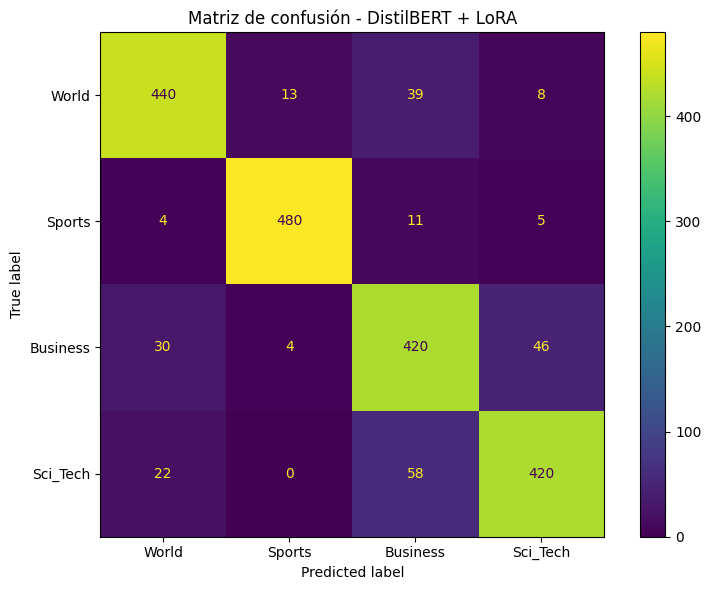

In [ ]:
# ==========================================
# Matriz de confusión
# ==========================================

matriz_confusion = confusion_matrix(
    labels_test,
    y_pred_test
)

nombres_clases = [
    id2label[i]
    for i in range(len(id2label))
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=nombres_clases
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Matriz de confusión - DistilBERT + LoRA"
)

plt.tight_layout()
plt.show()

### Observación de la matriz de confusión

La matriz de confusión confirma que `Sports` es la categoría mejor diferenciada por el modelo, con 480 clasificaciones correctas sobre 500 documentos.

La principal dificultad se concentra entre `Business` y `Sci_Tech`: 46 documentos de `Business` fueron clasificados como `Sci_Tech`, mientras que 58 documentos de `Sci_Tech` fueron clasificados como `Business`. También se observa cierta confusión entre `World` y `Business`, con 39 documentos de `World` clasificados como `Business`.

Estos resultados son consistentes con las métricas obtenidas previamente: `Business` presenta el menor F1-Score, mientras que `Sports` alcanza el mejor desempeño. La matriz permite localizar los errores y muestra que las dificultades del modelo no se distribuyen uniformemente entre las categorías.

## 18. Persistencia de resultados

Se persisten los resultados necesarios para documentar la rama Transformer y permitir su comparación posterior con el baseline clásico.

Las métricas finales y las predicciones sobre el conjunto de prueba se almacenan como tablas estructuradas, mientras que la matriz de confusión se conserva como figura. De esta manera, el Notebook 05 podrá reutilizar los resultados de evaluación sin necesidad de repetir el entrenamiento del modelo.

In [ ]:
# ==========================================
# Persistencia de la figura
# ==========================================

ruta_matriz_confusion = (
    OUTPUTS_FIGURES / "matriz_confusion_transformer_lora.png"
)

fig.savefig(
    ruta_matriz_confusion,
    dpi=300,
    bbox_inches="tight"
)

print("Figura guardada en:")
print(ruta_matriz_confusion)

Figura guardada en:
/content/proyecto_nlp_ds3/outputs/figures/matriz_confusion_transformer_lora.png


In [ ]:
# ==========================================
# Métricas finales del Transformer
# ==========================================

metricas_transformer = pd.DataFrame({
    "metrica": [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "tiempo_entrenamiento_segundos",
        "parametros_totales",
        "parametros_entrenables",
        "porcentaje_entrenable"
    ],
    "valor": [
        accuracy_test,
        precision_test,
        recall_test,
        f1_test,
        tiempo_entrenamiento_segundos,
        parametros_totales,
        parametros_entrenables,
        porcentaje_entrenable
    ]
})

metricas_transformer

,metrica,valor
0,accuracy,8.800000e-01
1,precision_macro,8.812932e-01
2,recall_macro,8.800000e-01
3,f1_macro,8.803905e-01
4,tiempo_entrenamiento_segundos,7.858076e+01
5,parametros_totales,6.769767e+07
6,parametros_entrenables,7.411240e+05
7,porcentaje_entrenable,1.094756e+00


In [ ]:
# ==========================================
# Persistencia de métricas
# ==========================================

ruta_metricas_transformer = (
    OUTPUTS_TABLES / "metricas_transformer_lora.csv"
)

metricas_transformer.to_csv(
    ruta_metricas_transformer,
    index=False
)

print("Métricas guardadas en:")
print(ruta_metricas_transformer)

Métricas guardadas en:
/content/proyecto_nlp_ds3/outputs/tables/metricas_transformer_lora.csv


In [ ]:
# ==========================================
# Persistencia de predicciones del Transformer
# ==========================================

df_predicciones_transformer = pd.DataFrame({
    "label_real_id": labels_test,
    "label_pred_id": y_pred_test
})

df_predicciones_transformer["label_real"] = (
    df_predicciones_transformer["label_real_id"].map(id2label)
)

df_predicciones_transformer["label_pred"] = (
    df_predicciones_transformer["label_pred_id"].map(id2label)
)

ruta_predicciones_transformer = (
    OUTPUTS_TABLES / "predicciones_transformer_lora.csv"
)

df_predicciones_transformer.to_csv(
    ruta_predicciones_transformer,
    index=False
)

print("Archivo:", ruta_predicciones_transformer)
print("Existe:", ruta_predicciones_transformer.exists())
print("Registros:", len(df_predicciones_transformer))

Archivo: /content/proyecto_nlp_ds3/outputs/tables/predicciones_transformer_lora.csv
Existe: True
Registros: 2000


In [ ]:
# ==========================================
# Comprimir todos los outputs de Colab
# ==========================================

import shutil

shutil.make_archive(
    "/content/outputs_notebook_04",
    "zip",
    "/content/proyecto_nlp_ds3/outputs"
)

print("ZIP creado:")
print("/content/outputs_notebook_04.zip")

ZIP creado:
/content/outputs_notebook_04.zip
